<a href="https://colab.research.google.com/github/AlanChi0720/bio_ai/blob/main/A_genomics_kmers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tour A: Genomics — DNA Sequence Classification with K-mers

**The idea:** A DNA sequence is just a string of A/T/G/C. One way to turn it into numbers is to count how often each short substring (k-mer) appears. A 4-mer is a 4-letter word like `ATCG` — there are 4^4 = 256 possible 4-mers. This "bag of k-mers" approach is simple but surprisingly powerful.

**What we'll build:** A classifier that predicts whether a DNA sequence is a **promoter region** (regulatory, initiates transcription) or a **random non-promoter** sequence.

**Estimated time:** 2–3 hours

In [1]:
!pip install -q biopython scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.7 MB/s eta 0:00:00


In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from Bio import SeqIO, Entrez
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

sns.set_theme(style='whitegrid')

# Set your NCBI email (required by their API terms)
Entrez.email = 'hc3331@nyu.edu'  # <-- change this

## 1. Get Promoter Sequences

We'll use the UCI ML promoter dataset — a classic benchmark with 106 E. coli promoter and non-promoter sequences.

In [3]:
import urllib.request

# UCI promoter gene sequences dataset (public domain)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data'
urllib.request.urlretrieve(url, 'promoters.data')

# Parse: each line is: class, name, sequence (tab-separated, sequence uses tabs between bases)
rows = []
with open('promoters.data') as f:
    for line in f:
        parts = line.strip().split(',')
        label = 1 if parts[0].strip() == '+' else 0
        seq = parts[2].replace('\t', '').replace(' ', '').upper()
        rows.append({'label': label, 'sequence': seq})

df = pd.DataFrame(rows)
print(df['label'].value_counts())
print('Example sequence:', df['sequence'].iloc[0])

label
1    53
0    53
Name: count, dtype: int64
Example sequence: TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT


## 2. K-mer Featurization

Each sequence becomes a vector of k-mer counts. This is conceptually similar to a bag-of-words in NLP, but for DNA.

In [4]:
K = 3  # try 2, 3, or 4

# Generate all possible k-mers
all_kmers = [''.join(p) for p in itertools.product('ATCG', repeat=K)]
kmer_to_idx = {km: i for i, km in enumerate(all_kmers)}

def seq_to_kmer_vector(seq, k=K):
    counts = Counter(seq[i:i+k] for i in range(len(seq) - k + 1))
    vec = np.zeros(len(all_kmers))
    for km, cnt in counts.items():
        if km in kmer_to_idx:
            vec[kmer_to_idx[km]] = cnt
    # Normalize by total k-mers to get frequencies
    total = vec.sum()
    return vec / total if total > 0 else vec

X = np.array([seq_to_kmer_vector(seq) for seq in df['sequence']])
y = df['label'].values
print(f'Feature matrix shape: {X.shape}  ({len(all_kmers)} possible {K}-mers)')

Feature matrix shape: (106, 64)  (64 possible 3-mers)


## 3. Train and Evaluate

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.3f}')
print()
print(classification_report(y_test, rf.predict(X_test), target_names=['Non-promoter', 'Promoter']))

AUC-ROC: 0.951

              precision    recall  f1-score   support

Non-promoter       0.88      1.00      0.93        14
    Promoter       1.00      0.85      0.92        13

    accuracy                           0.93        27
   macro avg       0.94      0.92      0.93        27
weighted avg       0.94      0.93      0.93        27



RandomForestClassifier(n_estimators=300, random_state=42)


## 4. Which K-mers Are Most Predictive?

/tmp/ipykernel_4147/3696281494.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=ax, palette='Greens_r')


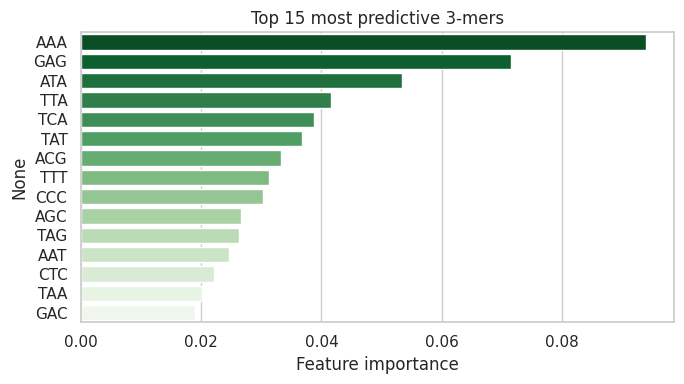

In [6]:
importances = pd.Series(rf.feature_importances_, index=all_kmers).nlargest(15)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, ax=ax, palette='Greens_r')
ax.set_title(f'Top 15 most predictive {K}-mers')
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()

# Q: Do any of these k-mers correspond to known promoter motifs?
# In E. coli, look for the -10 box (TATAAT) and -35 box (TTGACA).

## Reflection Questions

1. Try changing `K` to 2 or 4. Does model performance change?
2. The dataset is small (106 sequences). How confident are you in the AUC? How would you validate this more rigorously?
3. K-mer frequency ignores *position* — the -10 box is always at the same location in a promoter. Can you think of a representation that captures position?
4. Does this area interest you enough to continue to Phase 3 Track A?